In [24]:
import numpy as np
import rebound as rb
import einsteinpy.symbolic as es    
import scipy as sp 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sympy as sm




### Sistema de Unidades Geometrizadas

Para simplificar el cálculo numérico de las geodésicas y evitar inconsistencias de escala computacional, adoptamos el sistema de unidades geometrizadas, en el cual se define:

$$G = c = 1$$

Bajo este sistema, la masa $M$ del agujero negro define las escalas fundamentales de longitud y tiempo del problema. La Unidad de Longitud ($UL$) corresponde al radio gravitacional:

$$1 \text{ UL} = \frac{GM}{c^2}$$

De igual manera, la Unidad de Tiempo ($UT$) se define como el tiempo que tarda la luz en recorrer dicha distancia:

$$1 \text{ UT} = \frac{UL}{c} = \frac{GM}{c^3}$$

En estas unidades, el Radio de Schwarzschild para un agujero negro estático viene dado por $R_s = 2M$. 

**Nota computacional:** En los experimentos numéricos de este cuaderno estableceremos $M = 1$. Esto implica que todas las distancias y tiempos en nuestras simulaciones y gráficos estarán expresados implícitamente en múltiplos de la masa del agujero negro (por ejemplo, una coordenada radial $r = 6$ corresponderá a $r = 6M$).

In [15]:
# Definimos unidades basadas en un agujero negro de masa solar (M=1)
c = 1.0  # Velocidad de la luz [6]
G = 1.0  # Constante de gravitación [4]
M = 1.0  # Masa del objeto central

# Unidad de longitud (UL) = Radio gravitacional (GM/c^2)
UL = G * M / c**2 
# Unidad de tiempo (UT) = UL / c
UT = UL / c 

### Geodésicas en el Límite Newtoniano (Campo Débil)

Para establecer una base comparativa con los efectos relativistas puros, modelamos el comportamiento de las partículas mediante una métrica de campo débil (aproximación Newtoniana). Adoptando la signatura principalmente negativa $(+, -, -, -)$ vista en clase y nuestro sistema de unidades geometrizadas ($G=c=1$), el tensor métrico adopta la forma:

$$ds^2 = \left(1 - \frac{2M}{r}\right)dt^2 - dx^2 - dy^2 - dz^2$$

Utilizando la ecuación de la geodésica $\frac{dU^\mu}{d\tau} + \Gamma^\mu_{\alpha\beta}U^\alpha U^\beta = 0$, deducimos los símbolos de Christoffel relevantes para el movimiento. La evolución temporal del factor de Lorentz de la partícula ($U^t$) queda determinada por:

$$\frac{dU^t}{d\tau} = -\frac{2M U^t}{r^2(r - 2M)} (xU^x + yU^y + zU^z)$$

Mientras que para las componentes espaciales, la ecuación geodésica exacta para esta métrica nos da:

$$\frac{dU^i}{d\tau} = -\frac{M}{r^3}x^i (U^t)^2$$

*(Nota física: En el límite estrictamente clásico donde las velocidades son pequeñas respecto a la luz, el factor de Lorentz $U^t \approx 1$, por lo que recuperamos exactamente la aceleración gravitacional Newtoniana $\frac{d^2x^i}{dt^2} \approx -\frac{M}{r^3}x^i$. Sin embargo, en nuestras simulaciones numéricas conservaremos el término $(U^t)^2$ para que la integración paso a paso respecto al tiempo propio $\tau$ sea matemáticamente coherente con la métrica).*

In [16]:
def edg_newton(tau, Ys, G, M, c):
    """
    Ecuaciones diferenciales para la trayectoria en el límite Newtoniano/Campo Débil.
    Escritas de forma explícita para cada componente (sin factor común).
    Ys contiene: [T, x, y, z, Ut, Ux, Uy, Uz] donde T = c*t
    """
    T, x, y, z, Ut, Ux, Uy, Uz = Ys
    r = np.sqrt(x**2 + y**2 + z**2)
    
    # Evitar división por cero si la partícula cae al centro
    if r < 1e-5:
        return [0]*8
    
    # Derivadas de las coordenadas (Cuadrivelocidad)
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz
    
    # Componente temporal: dUt/dtau (Derivada de U^T)
    denom = (c**2 * r - 2 * G * M) * r**2
    dUt_dtau = -2 * G * M * Ut * (x*Ux + y*Uy + z*Uz) / denom
    
    # Componentes espaciales: dUi/dtau (Derivada de U^i)
    
    dUx_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * x
    dUy_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * y
    dUz_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * z
    
    return [dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau]

### Determinación de las Condiciones Iniciales y Normalización

Para iniciar la integración numérica de las geodésicas, es fundamental que el vector de estado inicial cumpla con la restricción de normalización de la cuadrivelocidad para partículas con masa. Utilizando la signatura principalmente negativa $(+, -, -, -)$, esta restricción viene definida por el invariante:

$$g_{\mu\nu} U^\mu U^\nu = c^2$$

Dado que conocemos la posición inicial $r_0$ y la velocidad espacial tridimensional respecto al tiempo coordenado $\vec{v} = (v^x, v^y, v^z)$, podemos relacionar las componentes espaciales de la cuadrivelocidad mediante $U^i = U^t \frac{v^i}{c}$ (o simplemente $U^i = U^t v^i$ en unidades relativistas donde $c=1$). 

Sustituyendo esta relación en la condición de normalización para una métrica espacialmente plana:

$$g_{00} (U^t)^2 - \delta_{ij} (U^t v^i)(U^t v^j) = c^2$$

Factorizando $(U^t)^2$ en el miembro izquierdo de la ecuación obtenemos:

$$(U^t)^2 \left( g_{00} - |\vec{v}|^2 \right) = c^2$$

Despejando la componente temporal $U^t$, obtenemos la ecuación que garantiza condiciones iniciales físicamente consistentes y evita soluciones imaginarias bajo el radical:

$$U^t_0 = \frac{c}{\sqrt{g_{00} - |\vec{v}|^2}}$$

En el sistema de unidades canónicas adoptado para la simulación ($c = 1, G = 1$), la expresión final se reduce a:

$$U^t_0 = \frac{1}{\sqrt{g_{00} - |\vec{v}|^2}}$$

In [17]:
t0 = 0.0
# Posición inicial de la partícula en el plano ecuatorial (UL)
x0, y0, z0 = 10.0, 0.0, 0.0
r0 = np.sqrt(x0**2 + y0**2 + z0**2)

# Velocidad inicial de coordenadas dada como fracción de c (adimensional)
vx0, vy0, vz0 = 0.0, 0.25, 0.0 
v_sq = vx0**2 + vy0**2 + vz0**2

# Componentes del tensor métrico inicial
g00 = 1.0 - (2.0 * G * M) / (c**2 * r0)
g11 = g22 = g33 = -1.0  # Espacio tridimensional plano y negativo

# Cálculo de la componente temporal de la cuadrivelocidad (U^T)

Ut0 = c / np.sqrt(g00 - v_sq)

# Transformación a las componentes espaciales de la cuadrivelocidad

Ux0 = vx0 * Ut0
Uy0 = vy0 * Ut0
Uz0 = vz0 * Ut0

# Vector de estado inicial para el integrador (solve_ivp): [T, x, y, z, Ut, Ux, Uy, Uz]

Y0 = [c * t0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]

### Integración Numérica de las Ecuaciones Geodésicas

La evolución del estado de la partícula se obtiene integrando numéricamente un sistema acoplado de ocho ecuaciones diferenciales ordinarias de primer orden, donde la variable independiente es el tiempo propio $\tau$:

$$
\frac{d x^\mu}{d\tau} = U^\mu, \quad \frac{d U^\mu}{d\tau} = -\Gamma^\mu_{\alpha\beta} U^\alpha U^\beta
$$

**Tiempo de Simulación (Tercera Ley de Kepler)**
Para que el intervalo de integración tenga sentido físico y nos permita observar exactamente una revolución completa de la partícula en el espacio, calculamos el período orbital clásico $T$ mediante la Tercera Ley de Kepler como límite final ($\tau_{\text{final}}$):

$$\tau_{\text{final}} = T = 2\pi \sqrt{\frac{r_0^3}{GM}}$$

**Método y Tolerancias**
Para resolver este sistema, empleamos el **método de Radau** mediante la función `solve_ivp`. Este esquema implícito se elige por su excelente estabilidad para resolver ecuaciones numéricamente rígidas (*stiff*), una condición típica en trayectorias de alta curvatura.

Para garantizar que el integrador conserve los invariantes físicos (energía, momento angular y la norma de la cuadrivelocidad $g_{\mu\nu}U^\mu U^\nu = c^2$), imponemos tolerancias de convergencia estrictas:
* **Tolerancia relativa (`rtol`):** $10^{-9}$
* **Tolerancia absoluta (`atol`):** $10^{-12}$

In [18]:
#  TIEMPO DE INTEGRACIÓN 

T_kepler = 2 * np.pi * np.sqrt(r0**3 / (G * M))

# Definimos el intervalo de integración (integraremos durante 1 período orbital completo)
tau_final = T_kepler
taus = np.linspace(0, tau_final, 2000)

#  INTEGRACIÓN NUMÉRICA 

solucion = solve_ivp(
    edg_newton, 
    [0.0, tau_final], 
    Y0, 
    args=(G, M, c), 
    t_eval=taus, 
    method='Radau',
    rtol=1e-9,   # Tolerancia relativa estricta para conservar constantes de movimiento
    atol=1e-12   # Tolerancia absoluta estricta
)


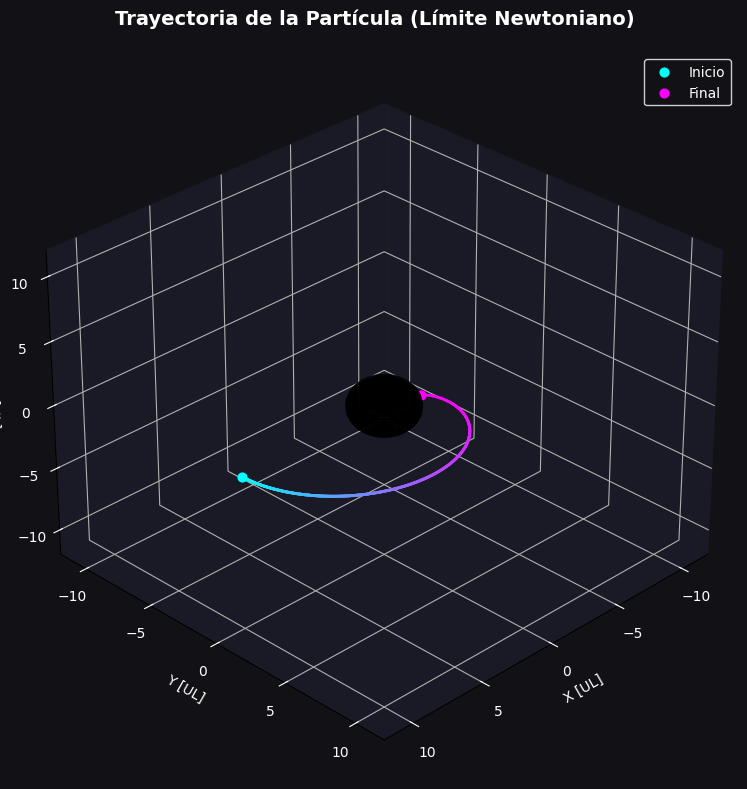

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- EXTRAER COORDENADAS DE LA PARTÍCULA DE CONTROL ---
x_p = solucion.y[1]
y_p = solucion.y[2]
z_p = solucion.y[3]
N_puntos = len(x_p)

# --- CREAR LA FIGURA 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Configuración del ángulo de visión (puedes ajustarlo a tu gusto)
ax.view_init(elev=30, azim=45)

# --- GRAFICAR LA TRAYECTORIA CON DEGRADADO (COLORMAP) ---
# Usamos un truco: graficamos pequeños segmentos para que cambien de color con el tiempo
# El color 'cool' va desde cyan (inicio) hasta magenta/rosado (final de la órbita)
cmap = plt.get_cmap('cool')
for i in range(N_puntos - 1):
    ax.plot(x_p[i:i+2], y_p[i:i+2], z_p[i:i+2], 
            color=cmap(i / N_puntos), alpha=0.8, linewidth=2.0)

# Marcamos explícitamente el punto inicial y final
ax.scatter(x_p[0], y_p[0], z_p[0], color='cyan', s=40, label='Inicio', zorder=5)
ax.scatter(x_p[-1], y_p[-1], z_p[-1], color='magenta', s=40, label='Final', zorder=5)

# --- DIBUJAR LA MASA CENTRAL (Radio de Schwarzschild como escala) ---
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.9, zorder=10)

# --- CONFIGURACIÓN ESTÉTICA EN FONDO OSCURO ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

# Oscurecer los planos de los ejes
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

# Etiquetas de los ejes
ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales basados en la posición inicial (con un margen)
lim = max(np.max(np.abs(x_p)), np.max(np.abs(y_p))) * 1.2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

# Título y leyenda
plt.title('Trayectoria de la Partícula (Límite Newtoniano)', 
          color='white', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', facecolor='#111116', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

### Integración de Múltiples Partículas

In [20]:
#  CONFIGURACIÓN DEL DISCO 
N_particulas = 500
resultados_disco_3d = [] # Aquí guardaremos todas las órbitas

# Límites del disco: Radio interno y externo 
r_min = 5.0
r_max = 15.0



for i in range(N_particulas):
    # 1. Posición inicial aleatoria en el plano (z=0)
    r0 = np.random.uniform(r_min, r_max)
    phi = np.random.uniform(0, 2 * np.pi) 
    
    x0 = r0 * np.cos(phi)
    y0 = r0 * np.sin(phi)
    z0 = 0.0
    
    # Velocidad inicial (Órbita circular Kepleriana clásica)
    # v = sqrt(GM/r). La proyectamos perpendicular al radio vector.
    v_mag = np.sqrt(G * M / r0)
    vx0 = -v_mag * np.sin(phi)
    vy0 = v_mag * np.cos(phi)
    vz0 = 0.0
    
    # Normalización y Cuadrivelocidad inicial (documento del profesor)
    g00 = 1.0 - (2.0 * G * M) / (c**2 * r0)
    g11 = g22 = g33 = -1.0
    
    Ut0 = 1.0 / np.sqrt(g00 + g11*vx0**2 + g22*vy0**2 + g33*vz0**2)
    Ux0 = vx0 * Ut0 / c
    Uy0 = vy0 * Ut0 / c
    Uz0 = vz0 * Ut0 / c
    
    Y0 = [0.0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]
    
    # Tiempo de integración (1 órbita completa exacta por partícula usando Kepler)
    T_kepler = 2 * np.pi * np.sqrt(r0**3 / (G * M))
    # Reducimos los puntos a 200 por órbita para no saturar la memoria gráfica con 500 líneas
    taus = np.linspace(0, T_kepler, 200) 
    
    # 5. Integración numérica
    sol = solve_ivp(
        edg_newton, 
        [0.0, T_kepler], 
        Y0, 
        args=(G, M, c), 
        t_eval=taus, 
        method='Radau',
        rtol=1e-7,  # Relajamos un poco las tolerancias para hacer más rápida la ejecución masiva
        atol=1e-10
    )
    
    # Guardamos la trayectoria en la lista
    resultados_disco_3d.append(sol.y)
    


Simulando 500 partículas. Esto tomará algunos segundos...


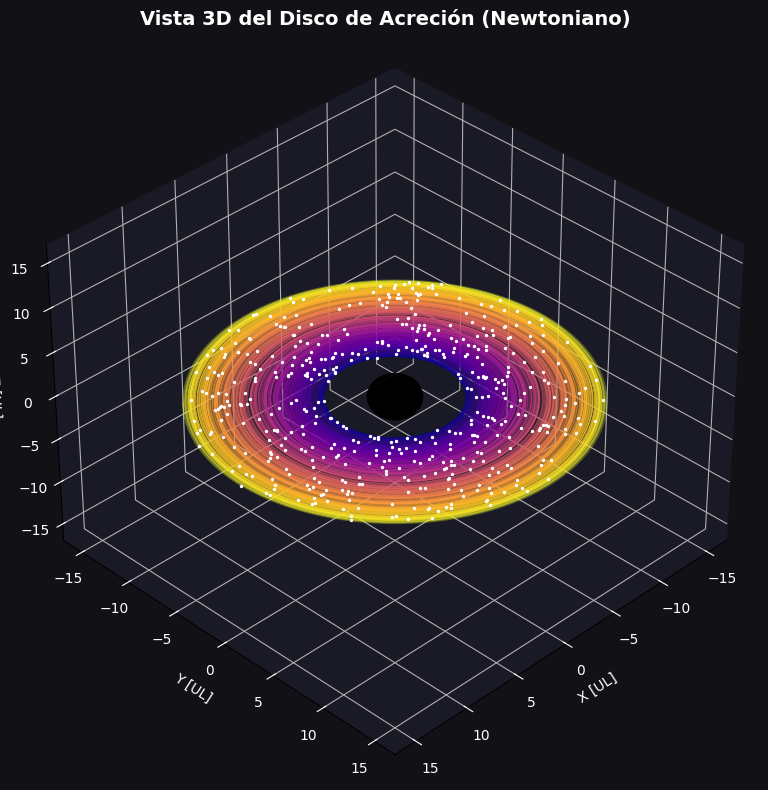

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- CONFIGURACIÓN DEL ÁNGULO ---
ax.view_init(elev=35, azim=45)

# --- DIBUJAR LAS 500 PARTÍCULAS ---
# Usamos un mapa de colores 'plasma' (naranja/morado) para colorearlas según su distancia
colores = cm.plasma(np.linspace(0, 1, len(resultados_disco_3d)))

for idx, y_particula in enumerate(resultados_disco_3d):
    x_p = y_particula[1]
    y_p = y_particula[2]
    z_p = y_particula[3]
    
    # Calculamos el radio promedio para darle color
    r_promedio = np.mean(np.sqrt(x_p**2 + y_p**2))
    color_asignado = cm.plasma((r_promedio - r_min) / (r_max - r_min))
    
    ax.plot(x_p, y_p, z_p, color=color_asignado, alpha=0.3, linewidth=0.8)
    ax.scatter(x_p[-1], y_p[-1], z_p[-1], color='white', s=2) # Puntos finales como "estrellas" o rocas

# --- DIBUJAR LA MASA CENTRAL ---
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.9, zorder=10)

# --- CONFIGURACIÓN ESTÉTICA ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales
lim = r_max + 2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Vista 3D del Disco de Acreción (Newtoniano)', 
          color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Geodésicas en la Métrica de Schwarzschild

Para estudiar la dinámica de partículas en regiones donde el campo gravitacional es intenso (como las cercanías del agujero negro central en nuestro disco de acreción), la aproximación Newtoniana deja de ser válida y debemos utilizar la métrica exacta de Schwarzschild.

La métrica de Schwarzschild (bajo la signatura $+,-,-,-$) se escribe en coordenadas esféricas $(t, r, \theta, \phi)$ como:

$$
\mathrm{d}s^2 = \left(1-\frac{2GM}{c^2 r}\right) c^2 \mathrm{d}t^2 - \left(1-\frac{2GM}{c^2 r}\right)^{-1}\mathrm{d}r^2 - r^2\mathrm{d}\theta^2 - r^2\sin^2\theta \mathrm{d}\phi^2
$$

A partir de esta métrica, podemos derivar los símbolos de Christoffel que dictan las ecuaciones de la geodésica.

In [29]:
G, M, c, T, r, teta, fi = sm.symbols('G M c T r theta phi')

gmat = np.diag([1-2*G*M/(c**2*r), -1/(1-2*G*M/(c**2*r)), -r**2, -r**2*sm.sin(teta)**2])
coordenadas = T, r, teta, fi
gmet = es.MetricTensor(gmat, coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)
display(gmet.tensor())
display(Gab.tensor())

[[-2*G*M/(c**2*r) + 1, 0, 0, 0], [0, -1/(-2*G*M/(c**2*r) + 1), 0, 0], [0, 0, -r**2, 0], [0, 0, 0, -r**2*sin(theta)**2]]

[[[0, G*M/(r*(-2*G*M + c**2*r)), 0, 0], [G*M/(r*(-2*G*M + c**2*r)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[-G*M*(2*G*M - c**2*r)/(c**4*r**3), 0, 0, 0], [0, G*M*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2), 0, 0], [0, 0, (2*G*M - c**2*r)/c**2, 0], [0, 0, 0, (2*G*M - c**2*r)*sin(theta)**2/c**2]], [[0, 0, 0, 0], [0, 0, 1/r, 0], [0, 1/r, 0, 0], [0, 0, 0, -sin(theta)*cos(theta)]], [[0, 0, 0, 0], [0, 0, 0, 1/r], [0, 0, 0, cos(theta)/sin(theta)], [0, 1/r, cos(theta)/sin(theta), 0]]]

### Ecuación de Movimiento

A partir de los símbolos de Christoffel obtenidos, construimos el sistema de ecuaciones diferenciales ordinarias de primer orden para nuestro integrador numérico. 

Siguiendo las indicaciones, a partir de este punto utilizaremos **unidades canónicas** donde $G = 1$ y $c = 1$. Esto implica que la masa $M$ define la escala de longitud y tiempo del sistema, de modo que el radio de Schwarzschild se reduce simplemente a $r_s = 2M$.

In [30]:
def edg_schwarzschild(tau, Ys, M):
    """
    Sistema de Ecuaciones Diferenciales Ordinarias para las geodésicas 
    en la métrica de Schwarzschild usando unidades donde G=1 y c=1.
    """
    # Desempaquetar el vector de estado
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys
    
    # Radio de Schwarzschild en unidades canónicas
    rs = 2 * M
    
    # 1. Derivadas de las coordenadas (es simplemente la cuadrivelocidad)
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi
    
    # 2. Derivadas de las componentes de la cuadrivelocidad (Ecuación geodésica)
    # dU^σ/dτ = - Γ^σ_{μν} U^μ U^ν
    
    # Componente t
    dUt_dtau = - (rs / (r * (r - rs))) * Ut * Ur
    
    # Componente r
    dUr_dtau = (- (rs * (r - rs) / (2 * r**3)) * Ut**2 
                + (rs / (2 * r * (r - rs))) * Ur**2 
                + (r - rs) * Utheta**2 
                + (r - rs) * np.sin(theta)**2 * Uphi**2)
    
    # Componente theta
    dUtheta_dtau = (- (2 / r) * Ur * Utheta 
                    + np.sin(theta) * np.cos(theta) * Uphi**2)
    
    # Componente phi
    dUphi_dtau = (- (2 / r) * Ur * Uphi 
                  - 2 * (np.cos(theta) / np.sin(theta)) * Utheta * Uphi)
    
    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau, 
            dUt_dtau, dUr_dtau, dUtheta_dtau, dUphi_dtau]

Probamos que funciona 

In [32]:
test_estado = [0.0, 10.0, np.pi/2, 0.0, 1.0, 0.0, 0.0, 0.1]
prueba_derivadas = edg_schwarzschild(0, test_estado, M=1.0)


prueba_derivadas

[1.0,
 0.0,
 0.0,
 0.1,
 -0.0,
 np.float64(0.07200000000000001),
 np.float64(6.123233995736767e-19),
 np.float64(-0.0)]

### Solución a las ecuaciones geodésica

Recordando que ya hemos adoptado nuestro sistema de unidades geometrizadas ($G = c = 1$) donde la masa central dicta la escala del sistema ($M = 1$), procedemos a establecer las condiciones iniciales para integrar la órbita.

A diferencia de la mecánica clásica, en Relatividad General las componentes de la velocidad inicial no son completamente arbitrarias. Para una partícula masiva, la cuadrivelocidad $U^\mu$ debe satisfacer en todo momento la condición de normalización sobre la métrica:

$$g_{\mu\nu} U^\mu U^\nu = 1$$

Dado un estado inicial de posición $(t_0, r_0, \theta_0, \phi_0)$ y unas velocidades espaciales iniciales $(U^r, U^\theta, U^\phi)$, estamos obligados a calcular la componente temporal de la cuadrivelocidad $U^t$ despejándola de la ecuación anterior. Para la métrica de Schwarzschild, esto resulta en:

$$U^t = \sqrt{\frac{1 - g_{rr}(U^r)^2 - g_{\theta\theta}(U^\theta)^2 - g_{\phi\phi}(U^\phi)^2}{g_{tt}}}$$

Con esta precaución física, garantizamos que la partícula arranque su trayectoria respetando la geometría del espacio-tiempo curvado.

### Condiciones iniciales en el espacio-tiempo

Recordando que ya hemos adoptado nuestro sistema de unidades geometrizadas ($G = 1, c = 1, M=1$), procedemos a establecer las condiciones iniciales. Para una partícula masiva, la cuadrivelocidad $U^\mu$ debe satisfacer la condición de normalización:

$$g_{\mu\nu} U^\mu U^\nu = 1$$

Dado un estado espacial inicial, despejamos la componente temporal $U^t$ para garantizar que la partícula respete la geometría del espacio-tiempo.

### Tiempos y condiciones iniciales: ¿Por cuánto tiempo integrar?
Vamos a usar la tercera ley de Kepler: $n^2 a^3 = \mu$. 
En nuestras unidades canónicas donde $\mu = M = 1$, el período orbital aproximado viene dado por $T_{kepler} = 2\pi \sqrt{r^3}$. Utilizaremos este tiempo como referencia para integrar varias órbitas y observar los efectos relativistas (como la precesión del perihelio).

In [33]:
# PARÁMETROS DEL SISTEMA 
M = 1.0             # Masa 
rs = 2.0 * M        # Radio de Schwarzschild

# POSICIÓN Y VELOCIDAD ESPACIAL INICIAL 
t0 = 0.0
r0 = 10.0 * M       # Arrancamos a 10 veces la masa de distancia
theta0 = np.pi / 2  # Plano ecuatorial 
phi0 = 0.0          # Ángulo azimutal inicial

# Velocidades iniciales 
Ur0 = 0.0           # Sin velocidad radial inicial 
Utheta0 = 0.0       # Sin movimiento vertical 
Uphi0 = 0.035       # Velocidad angular inicial.

#### Calculo de los cuadrivelocidades iniciales

In [34]:
g00 = (1.0 - rs / r0)
g11 = -1.0 / (1.0 - rs / r0)
g22 = -r0**2
g33 = -r0**2 * np.sin(theta0)**2

# Despejamos Ut garantizando que la norma sea 1 (partícula masiva)
Ut0 = np.sqrt((1.0 - (g11 * Ur0**2 + g22 * Utheta0**2 + g33 * Uphi0**2)) / g00)

# Empaquetamos el estado inicial completo
Y0 = [t0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

#### Integración numérica 

In [37]:
T_kepler = 2.0 * np.pi * np.sqrt(r0**3 / M)

# Vamos a integrar por 3 "años" keplerianos para ver bien la órbita
tau_final = 3.0 * T_kepler  
taus = np.linspace(0, tau_final, 5000)


sol_schwarzschild = solve_ivp(
    edg_schwarzschild, 
    [0.0, tau_final], 
    Y0, 
    args=(M,), 
    t_eval=taus, 
    method='Radau', 
    rtol=1e-9,      
    atol=1e-12
)

### Extracción de la solución y Graficación

El integrador numérico nos ha devuelto la evolución del vector de estado en función del tiempo propio $\tau$. Sin embargo, las coordenadas espaciales se encuentran en formato esférico $(r, \theta, \phi)$. 

Para visualizar la trayectoria en el espacio tridimensional, debemos aplicar la transformación estándar a coordenadas cartesianas:

$$x = r \sin(\theta) \cos(\phi)$$
$$y = r \sin(\theta) \sin(\phi)$$
$$z = r \cos(\theta)$$

A continuación, extraemos estos datos, aplicamos la transformación y graficamos la órbita geodésica, incluyendo una representación esférica del horizonte de eventos (el radio de Schwarzschild, $r_s = 2M$) en el centro del sistema.

In [38]:
r_sol = sol_schwarzschild.y[1]
theta_sol = sol_schwarzschild.y[2]
phi_sol = sol_schwarzschild.y[3]

# Transformamos a cartesianas
x_sol = r_sol * np.sin(theta_sol) * np.cos(phi_sol)
y_sol = r_sol * np.sin(theta_sol) * np.sin(phi_sol)
z_sol = r_sol * np.cos(theta_sol)
N_puntos = len(x_sol)

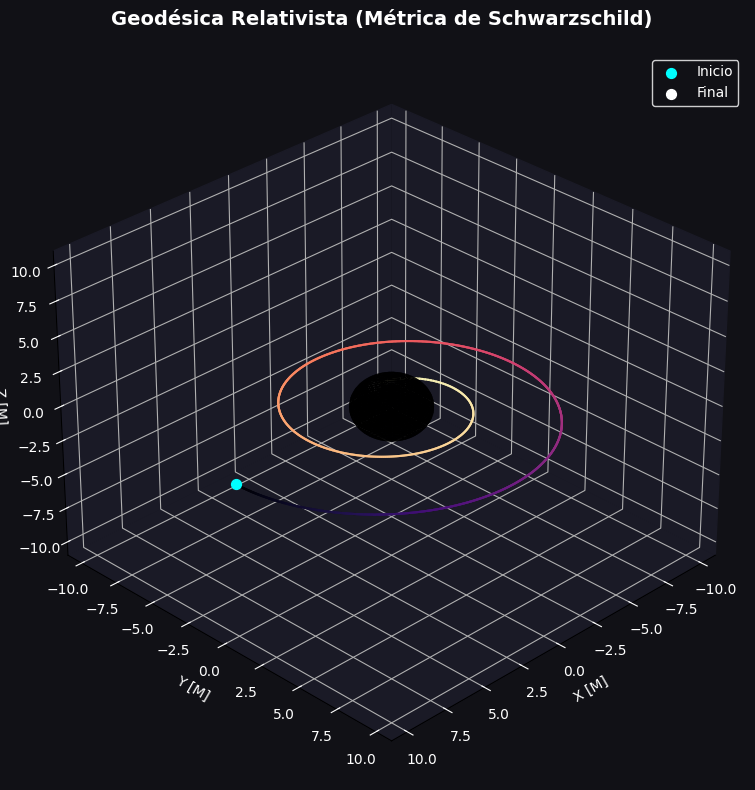

In [39]:
# --- 2. CONFIGURACIÓN DE LA FIGURA 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=30, azim=45) # Ángulo de visión

# --- 3. DIBUJAR LA GEODÉSICA (Con mapa de color temporal) ---
# Usamos un mapa de colores 'magma' para ver la evolución (de oscuro a brillante)
cmap = plt.get_cmap('magma')
for i in range(N_puntos - 1):
    ax.plot(x_sol[i:i+2], y_sol[i:i+2], z_sol[i:i+2], 
            color=cmap(i / N_puntos), alpha=0.9, linewidth=1.5)

# Puntos de inicio y fin
ax.scatter(x_sol[0], y_sol[0], z_sol[0], color='cyan', s=50, label='Inicio', zorder=5)
ax.scatter(x_sol[-1], y_sol[-1], z_sol[-1], color='white', s=50, label='Final', zorder=5)

# --- 4. DIBUJAR EL AGUJERO NEGRO (Horizonte de Eventos) ---
# En nuestras unidades, rs = 2.0 * M
rs_grafico = 2.0 * M
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs_grafico * np.outer(np.cos(u), np.sin(v))
y_bh = rs_grafico * np.outer(np.sin(u), np.sin(v))
z_bh = rs_grafico * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=1.0, zorder=10)

# --- 5. CONFIGURACIÓN ESTÉTICA ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [M]', color='white')
ax.set_ylabel('Y [M]', color='white')
ax.set_zlabel('Z [M]', color='white')
ax.tick_params(colors='white')

# Límites dinámicos para que la órbita quepa perfecta
lim = max(np.max(np.abs(x_sol)), np.max(np.abs(y_sol))) * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Geodésica Relativista (Métrica de Schwarzschild)', 
          color='white', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', facecolor='#111116', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

#### Grafica de la órbita geodésica para múltiples partículas

### Simulación de un Disco de Acreción Relativista

Habiendo comprobado la correcta integración de una geodésica individual, procedemos a simular un ensamble estelar o disco de polvo alrededor del agujero negro. 

A diferencia del caso Newtoniano, la Relatividad General impone un límite físico estricto conocido como la Órbita Circular Estable Más Interna (ISCO). Para la métrica de Schwarzschild, la ISCO se ubica en $r = 6M$. Las partículas con radios menores a este límite no pueden mantener órbitas circulares estables y precipitan hacia el horizonte de eventos. 

Por lo tanto, distribuiremos aleatoriamente 500 partículas en el plano ecuatorial ($\theta = \pi/2$) con radios comprendidos entre $r_{min} = 6M$ y un $r_{max}$ arbitrario. Calcularemos la cuadrivelocidad temporal $U^t$ para cada una, garantizando que todo el disco respete la condición de normalización $g_{\mu\nu}U^\mu U^\nu = 1$, y visualizaremos el resultado transformando las coordenadas a un espacio cartesiano.

In [40]:
#  CONFIGURACIÓN DEL DISCO 
N_particulas = 500
M = 1.0
rs = 2.0 * M

r_min = 6.0 * M  
r_max = 20.0 * M 

# Listas para guardar las trayectorias cartesianas
resultados_x = []
resultados_y = []
resultados_z = []
radios_iniciales = []



# INTEGRACIÓN MASIVA 
for i in range(N_particulas):
    # Condiciones espaciales aleatorias
    r0 = np.random.uniform(r_min, r_max)
    phi0 = np.random.uniform(0, 2 * np.pi)
    theta0 = np.pi / 2  # Disco ecuatorial
    
    # Velocidades 
    Ur0 = 0.0
    Utheta0 = 0.0
    Uphi0 = np.sqrt(M / r0) / r0  # dphi/dtau
    
    # Cálculo de U^t para cada partícula
    g_00 = (1.0 - rs / r0)
    g_11 = -1.0 / (1.0 - rs / r0)
    g_22 = -r0**2
    g_33 = -r0**2
    
    Ut0 = np.sqrt((1.0 - (g_11*Ur0**2 + g_22*Utheta0**2 + g_33*Uphi0**2)) / g_00)
    Y0 = [0.0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]
    
    # Tiempo de integración 
    T_kepler = 2.0 * np.pi * np.sqrt(r0**3 / M)
    tau_final = 1.2 * T_kepler
    taus = np.linspace(0, tau_final, 100) # 100 puntos por partícula es suficiente
    
    # Integrador
    sol = solve_ivp(edg_schwarzschild, [0.0, tau_final], Y0, args=(M,), 
                    t_eval=taus, method='Radau', rtol=1e-5, atol=1e-8)
    
    # Extraer y transformar a cartesianas inmediatamente para no saturar memoria
    r_sol = sol.y[1]
    th_sol = sol.y[2]
    ph_sol = sol.y[3]
    
    resultados_x.append(r_sol * np.sin(th_sol) * np.cos(ph_sol))
    resultados_y.append(r_sol * np.sin(th_sol) * np.sin(ph_sol))
    resultados_z.append(r_sol * np.cos(th_sol))
    radios_iniciales.append(r0)
    


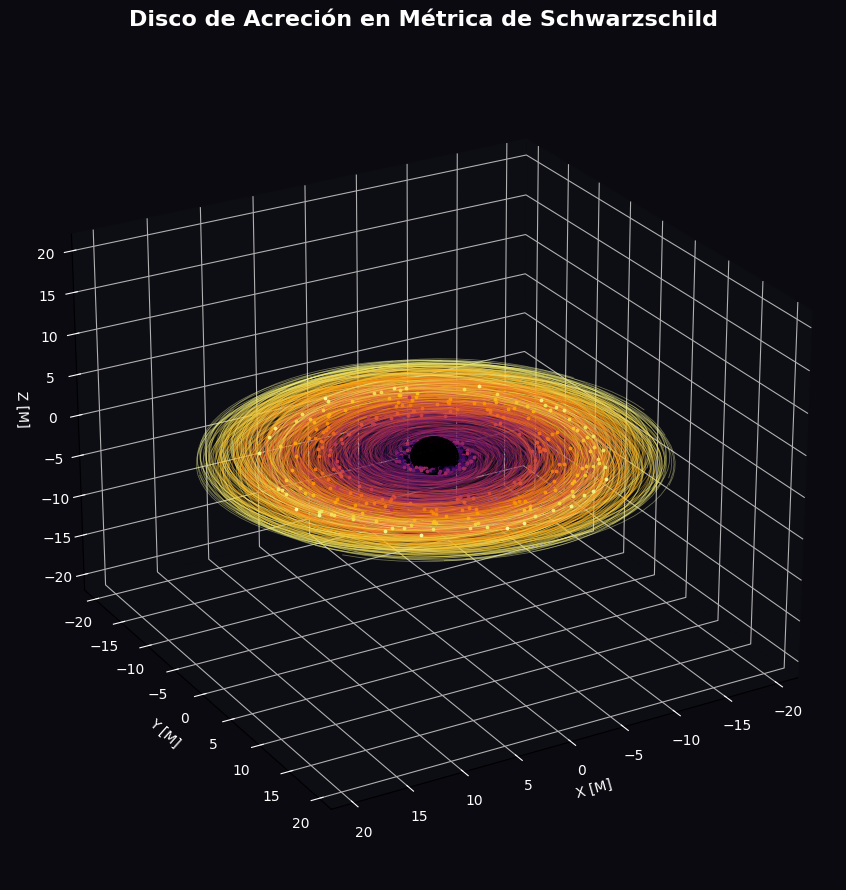

In [41]:
# --- 3. GRAFICACIÓN DEL DISCO 3D ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=25, azim=60)

# Colores basados en el radio inicial (gradiente térmico figurativo)
colores = cm.inferno((np.array(radios_iniciales) - r_min) / (r_max - r_min))

for i in range(N_particulas):
    ax.plot(resultados_x[i], resultados_y[i], resultados_z[i], 
            color=colores[i], alpha=0.4, linewidth=0.6)
    # Partícula final brillante
    ax.scatter(resultados_x[i][-1], resultados_y[i][-1], resultados_z[i][-1], 
               color=colores[i], s=3, alpha=0.9)

# Agujero Negro Central (r = 2M)
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs * np.outer(np.cos(u), np.sin(v))
y_bh = rs * np.outer(np.sin(u), np.sin(v))
z_bh = rs * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=1.0, zorder=10)

# Estética
ax.set_facecolor('#0a0a10')
fig.patch.set_facecolor('#0a0a10')
ax.xaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.yaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.zaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))

ax.set_xlabel('X [M]', color='white')
ax.set_ylabel('Y [M]', color='white')
ax.set_zlabel('Z [M]', color='white')
ax.tick_params(colors='white')

lim = r_max * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Disco de Acreción en Métrica de Schwarzschild', 
          color='white', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()